In [5]:
import numpy as np
import pandas as pd

In [6]:
train_df= pd.read_csv('PubMed_200k_RCT/train.csv')
dev_df = pd.read_csv('PubMed_200k_RCT/dev.csv')
test_df = pd.read_csv('PubMed_200k_RCT/test.csv')
train_df.head()

,abstract_id,line_id,abstract_text,line_number,total_lines,target
0,24491034,24491034_0_11,The emergence of HIV as a chronic condition me...,0,11,BACKGROUND
1,24491034,24491034_1_11,This paper describes the design and evaluation...,1,11,BACKGROUND
2,24491034,24491034_2_11,This study is designed as a randomised control...,2,11,METHODS
3,24491034,24491034_3_11,The intervention group will participate in the...,3,11,METHODS
4,24491034,24491034_4_11,The program is based on self-efficacy theory a...,4,11,METHODS


In [9]:
train_df = train_df.dropna(subset=['abstract_text'])
print(train_df['abstract_text'].isna().sum())
print(dev_df['abstract_text'].isna().sum())
print(test_df['abstract_text'].isna().sum())
print(train_df.describe())
print(train_df.info())

0
0
0
        abstract_id   line_number   total_lines
count  2.211860e+06  2.211860e+06  2.211860e+06
mean   1.777430e+07  5.709641e+00  1.241928e+01
std    5.372625e+06  4.054368e+00  3.317234e+00
min    1.279170e+06  0.000000e+00  3.000000e+00
25%    1.282092e+07  2.000000e+00  1.000000e+01
50%    1.850567e+07  5.000000e+00  1.200000e+01
75%    2.234881e+07  8.000000e+00  1.400000e+01
max    2.652916e+07  5.000000e+01  5.100000e+01
<class 'pandas.core.frame.DataFrame'>
Index: 2211860 entries, 0 to 2211860
Data columns (total 6 columns):
 #   Column         Dtype 
---  ------         ----- 
 0   abstract_id    int64 
 1   line_id        object
 2   abstract_text  object
 3   line_number    int64 
 4   total_lines    int64 
 5   target         object
dtypes: int64(3), object(3)
memory usage: 118.1+ MB
None


In [4]:
print(dev_df.describe())
print(dev_df.info())

        abstract_id   line_number   total_lines
count  2.893200e+04  28932.000000  28932.000000
mean   1.781278e+07      5.676172     12.352343
std    5.356084e+06      3.999521      3.176805
min    1.336526e+06      0.000000      4.000000
25%    1.287862e+07      2.000000     10.000000
50%    1.855817e+07      5.000000     12.000000
75%    2.239816e+07      8.000000     14.000000
max    2.643621e+07     27.000000     28.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28932 entries, 0 to 28931
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   abstract_id    28932 non-null  int64 
 1   line_id        28932 non-null  object
 2   abstract_text  28932 non-null  object
 3   line_number    28932 non-null  int64 
 4   total_lines    28932 non-null  int64 
 5   target         28932 non-null  object
dtypes: int64(3), object(3)
memory usage: 1.3+ MB
None


In [5]:
print(test_df.describe())
print(test_df.info())

        abstract_id   line_number   total_lines
count  2.949300e+04  29493.000000  29493.000000
mean   1.773442e+07      5.805344     12.610687
std    5.390987e+06      4.093325      3.279820
min    1.334248e+06      0.000000      4.000000
25%    1.273415e+07      2.000000     10.000000
50%    1.832493e+07      5.000000     12.000000
75%    2.236804e+07      9.000000     14.000000
max    2.642272e+07     27.000000     28.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29493 entries, 0 to 29492
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   abstract_id    29493 non-null  int64 
 1   line_id        29493 non-null  object
 2   abstract_text  29493 non-null  object
 3   line_number    29493 non-null  int64 
 4   total_lines    29493 non-null  int64 
 5   target         29493 non-null  object
dtypes: int64(3), object(3)
memory usage: 1.4+ MB
None


In [10]:
# # Drop the unneccassry column
train_df = train_df.drop(columns=['abstract_id', 'line_id'])
dev_df = dev_df.drop(columns=['abstract_id', 'line_id'])
# med_data_test = med_data_test.drop(columns=['abstract_id', 'line_id'])
dev_df.head()

,abstract_text,line_number,total_lines,target
0,Adrenergic activation is thought to be an impo...,0,9,BACKGROUND
1,Systemic venous norepinephrine was measured at...,1,9,RESULTS
2,Baseline norepinephrine level was associated w...,2,9,RESULTS
3,"On multivariate analysis , baseline norepineph...",3,9,RESULTS
4,"In contrast , the relation of the change in no...",4,9,RESULTS


In [11]:
X_train_text = train_df["abstract_text"].astype(str)
y_train = train_df["target"]

X_dev_text = dev_df["abstract_text"].astype(str)
y_dev = dev_df["target"]

X_test_text = test_df["abstract_text"].astype(str)
y_test = test_df["target"]

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# tfidf = TfidfVectorizer(
#     ngram_range = (1,2),
#     max_features = 60000,
#     sublinear_tf = True)

# X_train = tfidf.fit_transform(X_train_text)
# X_dev = tfidf.transform(X_dev_text)
# X_test = tfidf.transform(X_test_text)

# X_train.shape, X_test.shape

import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import FeatureUnion

word_tfidf = TfidfVectorizer(
    ngram_range=(1,2),
    max_features=30000,
    dtype=np.float32
)

char_tfidf = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3,4),   # reduce upper bound
    max_features=15000,
    dtype=np.float32
)

vectorizer = FeatureUnion([
    ("word", word_tfidf),
    ("char", char_tfidf)
])

X_train = vectorizer.fit_transform(X_train_text)
X_test  = vectorizer.transform(X_test_text)

In [10]:
## SVM Model
def build_svm(C = 1.0):
    return LinearSVC( C = C, class_weight = "balanced", random_state = 42)

In [11]:
model = build_svm(C= 0.1)
model.fit(X_train, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,0.1
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,verbose,0
,random_state,42


In [12]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred, digits = 4))

              precision    recall  f1-score   support

  BACKGROUND     0.6572    0.6782    0.6675      2663
 CONCLUSIONS     0.7893    0.8202    0.8044      4426
     METHODS     0.9062    0.9342    0.9200      9751
   OBJECTIVE     0.7324    0.6643    0.6967      2377
     RESULTS     0.9184    0.8882    0.9030     10276

    accuracy                         0.8562     29493
   macro avg     0.8007    0.7970    0.7983     29493
weighted avg     0.8564    0.8562    0.8559     29493



In [13]:
labels = ["BACKGROUND", "OBJECTIVE", "METHODS", "RESULTS", "CONCLUSIONS"]
cm = confusion_matrix(y_test, y_pred, labels = labels)

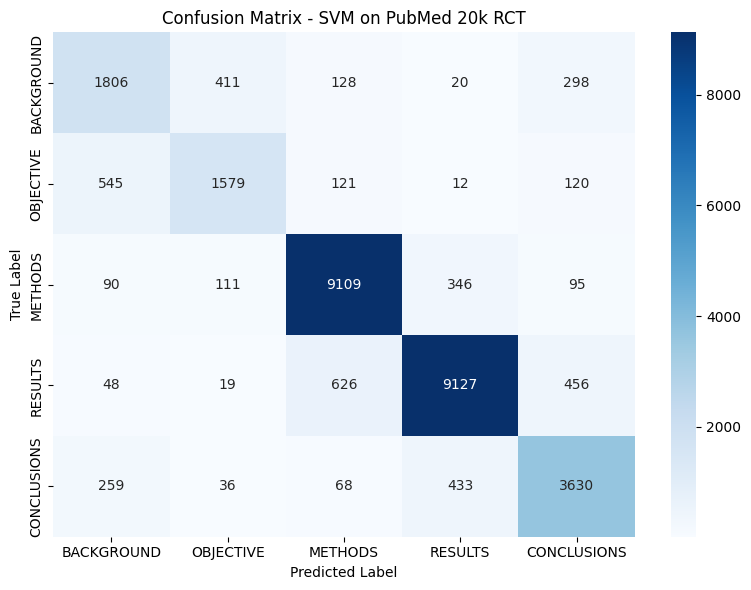

In [14]:
plt.figure(figsize = (8,6))
sns.heatmap(cm, annot = True, fmt ="d", cmap = "Blues", xticklabels = labels, yticklabels = labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - SVM on PubMed 20k RCT")
plt.tight_layout()
plt.show()

In [15]:
test_df["predicted"] = y_pred
errors = test_df[test_df["target"] != test_df["predicted"]]
errors[["abstract_text", "target", "predicted"]].head(10)

,abstract_text,target,predicted
3,"In addition , we compared plasma levels of MAp...",BACKGROUND,METHODS
18,The purpose of these two studies was to define...,BACKGROUND,OBJECTIVE
25,In this study failures ( > 3 vomiting ) were r...,RESULTS,METHODS
49,Acupuncture and needle contact were superior t...,RESULTS,CONCLUSIONS
52,The auricular area we chose for stimulation wa...,CONCLUSIONS,BACKGROUND
67,A lack of significant differences between pati...,CONCLUSIONS,RESULTS
68,"This two-way , randomized , single-dose , cros...",BACKGROUND,METHODS
91,The Sun Exposure and Vitamin D Supplementation...,BACKGROUND,OBJECTIVE
94,This paper discusses the rationale behind the ...,CONCLUSIONS,BACKGROUND
98,IORT can be provided as accelerated partial br...,BACKGROUND,CONCLUSIONS


In [16]:
feature_names = np.array(vectorizer.get_feature_names_out())

for i, label in enumerate(model.classes_):
    top_features = np.argsort(model.coef_[i])[-20:]
    print(f"\nTop features for class: {label}")
    print(feature_names[top_features])


Top features for class: BACKGROUND
['char__ctr' 'word__objective of' 'word__was developed' 'char__ct0'
 'word__was designed' 'word__previous study' 'word__trial demonstrated'
 'word__are' 'word__trial showed' 'word__not known'
 'word__guidelines recommend' 'word__conducted to' 'word__we previously'
 'char__ ( ' 'word__have' 'char__ ( c' 'word__is' 'char__ntr' 'char__ to'
 'char__ to ']

Top features for class: CONCLUSIONS
['word__we believe' 'word__knowledge this' 'word__studies are'
 'char__ c )' 'word__our data' 'word__should' 'word__concluded that'
 'char__( c' 'word__compared to' 'word__has no' 'word__further research'
 'word__was effective' 'word__we suggest' 'char__. )'
 'word__compared with' 'word__further studies' 'word__these data'
 'word__we recommend' 'char__ to' 'char__ to ']

Top features for class: METHODS
['word__were measured' 'word__randomly' 'word__was administered'
 'word__was given' 'word__of predicted' 'char__ of ' 'word__was compared'
 'word__study provides' 'wor

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

char_vectorizer = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3,6),
    min_df=3,
    max_df=0.9
)

In [14]:
from sklearn.pipeline import FeatureUnion
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

word_vectorizer = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1,2),
    min_df=3,
    max_df=0.9
)

combined_features = FeatureUnion([
    ("word_tfidf", word_vectorizer),
    ("char_tfidf", char_vectorizer)
])

model = Pipeline([
    ("features", combined_features),
    ("clf", LinearSVC())
])

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "clf__C": [0.01, 0.1, 1, 10]
}

grid = GridSearchCV(model, param_grid, cv=5, scoring="f1_macro")
grid.fit(train_df['abstract_text'], y_train)

print(grid.best_params_)

/home/cse23160/Downloads/Cryptomedbench/tf_env/lib/python3.10/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/cse23160/Downloads/Cryptomedbench/tf_env/lib/python3.10/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [ ]:
train_df["target"].value_counts()

In [ ]:
y_pred = grid.predict(test_df['abstract_text'])

print(classification_report(y_test, y_pred, digits = 4))

In [ ]:
from sklearn.svm import LinearSVC

model = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2))),
    ("clf", LinearSVC(class_weight="balanced"))
])

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(train_df["target"])
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["target"]
)

class_weights = dict(zip(classes, weights))
print(class_weights)

In [ ]:
LinearSVC(class_weight=class_weights)

In [ ]:
min_count = train_df["target"].value_counts().min()

balanced_df = (
    train_df
    .groupby("target")
    .apply(lambda x: x.sample(min_count, random_state=42))
    .reset_index(drop=True)
)

In [ ]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)

X_resampled, y_resampled = ros.fit_resample(
    train_df["abstract_text"].values.reshape(-1,1),
    train_df["target"]
)

X_resampled = X_resampled.flatten()

In [ ]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1,3),
        min_df=3,
        max_df=0.9
    )),
    ("clf", LinearSVC(
        C=0.1,
        class_weight="balanced"
    ))
])

In [ ]:
pipeline.fit(X_resampled, y_resampled)

In [ ]:
y_pred = pipeline.predict(test_df['abstract_text'])

print(classification_report(y_test, y_pred, digits = 4))

In [ ]:
labels = ["BACKGROUND", "OBJECTIVE", "METHODS", "RESULTS", "CONCLUSIONS"]
cm = confusion_matrix(y_test, y_pred, labels = labels)
plt.figure(figsize = (8,6))
sns.heatmap(cm, annot = True, fmt ="d", cmap = "Blues", xticklabels = labels, yticklabels = labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - SVM on PubMed 20k RCT (Class Balanced)")
plt.tight_layout()
plt.show()

In [ ]:
import joblib

# Save
joblib.dump(grid, "svm_model.pkl")

# Load
model = joblib.load("svm_model.pkl")